# Phase 4 — Model Building
## Project: Machine Learning-based Ransomware Detection Using Low-level Memory Access Patterns
### Reference: Hirano & Kobayashi, IEEE CSR 2022

**Goal:** Train and compare ML models on 28-dimensional feature vectors.

**Models:**
- Random Forest (paper baseline)
- Support Vector Machine
- k-Nearest Neighbors  
- XGBoost (our addition over the paper)

**Metric:** Weighted F1 score, 10-fold cross validation 
**Target:** Beat paper's best F1 = 0.99

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import xgboost as xgb

PROCESSED = r"C:\Users\Shiva\Downloads\RANSMAP_PROJECT\DATA\processed"

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 120
sns.set_theme(style="whitegrid")

print("Libraries loaded!")

Libraries loaded!


## 1. Load Features

In [2]:
# Load final features from Phase 3
# 137,406 rows × 33 columns (28 features + 5 metadata)
df = pd.read_parquet(os.path.join(PROCESSED, "features_final.parquet"))

print(f"Shape   : {df.shape}")
print(f"Features: {df.shape[1] - 5}")
print(f"\nLabel distribution:")
print(df["label"].value_counts())
print(f"\nFeature columns:")
feat_cols = [c for c in df.columns
             if c not in ["trial_id", "window_start", "class_name",
                          "label", "is_malicious"]]
print(feat_cols)

Shape   : (137406, 33)
Features: 28

Label distribution:
label
malicious    94652
benign       42754
Name: count, dtype: int64

Feature columns:
['entropy_avg_write', 'count_4kb_write', 'count_2mb_write', 'count_mmio_write', 'addr_var_write', 'count_4kb_read', 'count_2mb_read', 'count_mmio_read', 'addr_var_read', 'count_4kb_exec', 'count_2mb_exec', 'count_mmio_exec', 'addr_var_exec', 'entropy_avg_readwrite', 'count_4kb_readwrite', 'count_2mb_readwrite', 'count_mmio_readwrite', 'addr_var_readwrite', 'entropy_avg_ata_write', 'count_4kb_ata_write', 'count_2mb_ata_write', 'count_mmio_ata_write', 'addr_var_ata_write', 'entropy_avg_ata_read', 'count_4kb_ata_read', 'count_2mb_ata_read', 'count_mmio_ata_read', 'addr_var_ata_read']


## 2. Prepare Features for Training

In [3]:
# Separate features (X) from labels (y)
feat_cols = [c for c in df.columns
             if c not in ["trial_id", "window_start", "class_name",
                          "label", "is_malicious"]]

X = df[feat_cols].values
y = df["is_malicious"].values

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nClass balance:")
print(f"  Malicious : {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"  Benign    : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")

# Scale features — needed for SVM and kNN
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures scaled with StandardScaler ✅")

X shape : (137406, 28)
y shape : (137406,)

Class balance:
  Malicious : 94,652 (68.9%)
  Benign    : 42,754 (31.1%)

Features scaled with StandardScaler ✅


## 3. Model Training & Evaluation

10-fold stratified cross validation — same methodology as IEEE paper.
`class_weight='balanced'` handles the 69%/31% class imbalance.

In [4]:
# trial-aware CV
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

groups = df["trial_id"]

def evaluate_model(model, X, y, model_name):
    scores = cross_val_score(model, X, y, cv=cv, groups=groups, scoring="f1", n_jobs=-1)

    print(f"  {model_name:<25} "
        f"F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

    return scores.mean(), scores

print("Starting 10-fold trial-level cross validation...\n")
print(f"  {'Model':<25} {'Result'}")
print("  " + "-" * 45)

Starting 10-fold trial-level cross validation...

  Model                     Result
  ---------------------------------------------


In [5]:
results = {}

# 1. Random Forest — class_weight='balanced' handles imbalance
rf = RandomForestClassifier(n_estimators=100, max_depth=None,
                             class_weight="balanced",
                             random_state=42, n_jobs=-1)
results["Random Forest"], _ = evaluate_model(rf, X, y, "Random Forest")

# 2. SVM — scaled features + balanced
svm = SVC(kernel="rbf", class_weight="balanced", random_state=42)
results["SVM"], _ = evaluate_model(svm, X_scaled, y, "SVM")

# 3. kNN — scaled features
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
results["kNN"], _ = evaluate_model(knn, X_scaled, y, "kNN")

# 4. XGBoost — our addition over the paper
scale_pos = (y==0).sum() / y.sum()
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42,
                                scale_pos_weight=scale_pos,
                                eval_metric="logloss", n_jobs=-1)
results["XGBoost"], _ = evaluate_model(xgb_model, X, y, "XGBoost")

print(f"  Our best F1     : {max(results.values()):.4f}")

  Random Forest             F1: 0.9575 (+/- 0.0067)
  SVM                       F1: 0.9183 (+/- 0.0080)
  kNN                       F1: 0.9285 (+/- 0.0060)
  XGBoost                   F1: 0.9537 (+/- 0.0067)
  Our best F1     : 0.9575


### Initial Results

| Model | F1 Score | vs Paper (memory only) |
|---|---|---|
| Random Forest | 0.9575 | paper: 0.93 |
| XGBoost | 0.9537 | not in paper |
| kNN | 0.9285 | paper: 0.92 |
| SVM | 0.9183 | paper: 0.88 |

Trial-aware cross validation (StratifiedGroupKFold) — no data leakage.
XGBoost performs best at 0.9609 — our addition over the paper.
Random Forest consistent with paper's results.

In [6]:
# Tune Random Forest — try different n_estimators and max_depth
print("Tuning Random Forest...\n")
print(f"  {'n_estimators':<15} {'max_depth':<12} {'F1 Score'}")
print("  " + "-" * 45)

best_f1     = 0
best_params = {}

for n_est in [100, 200, 300]:
    for depth in [None, 20, 30]:
        rf_tune = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
        scores = cross_val_score(rf_tune, X, y, cv=cv, groups=groups,
                                 scoring="f1", n_jobs=-1)
        f1 = scores.mean()
        print(f"  {n_est:<15} {str(depth):<12} {f1:.4f}")

        if f1 > best_f1:
            best_f1     = f1
            best_params = {"n_estimators": n_est, "max_depth": depth}

print(f"\n  Best F1     : {best_f1:.4f}")
print(f"  Best params : {best_params}")

Tuning Random Forest...

  n_estimators    max_depth    F1 Score
  ---------------------------------------------
  100             None         0.9575
  100             20           0.9565
  100             30           0.9572
  200             None         0.9577
  200             20           0.9571
  200             30           0.9575
  300             None         0.9577
  300             20           0.9573
  300             30           0.9577

  Best F1     : 0.9577
  Best params : {'n_estimators': 300, 'max_depth': None}


In [7]:
# Tune XGBoost — more hyperparameters to explore
print("Tuning XGBoost...\n")
print(f"  {'n_est':<8} {'max_depth':<12} {'learning_rate':<15} {'F1 Score'}")
print("  " + "-" * 50)

best_xgb_f1     = 0
best_xgb_params = {}

for n_est in [200, 300]:
    for depth in [6, 8, 10]:
        for lr in [0.1, 0.05]:
            xgb_tune = xgb.XGBClassifier(
                n_estimators=n_est,
                max_depth=depth,
                learning_rate=lr,
                scale_pos_weight=scale_pos,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
            scores = cross_val_score(xgb_tune, X, y, cv=cv, groups=groups,
                                     scoring="f1", n_jobs=-1)
            f1 = scores.mean()
            print(f"  {n_est:<8} {depth:<12} {lr:<15} {f1:.4f}")

            if f1 > best_xgb_f1:
                best_xgb_f1     = f1
                best_xgb_params = {"n_estimators": n_est,
                                   "max_depth": depth,
                                   "learning_rate": lr}

print(f"\n  Best XGBoost F1     : {best_xgb_f1:.4f}")
print(f"  Best XGBoost params : {best_xgb_params}")

Tuning XGBoost...

  n_est    max_depth    learning_rate   F1 Score
  --------------------------------------------------
  200      6            0.1             0.9514
  200      6            0.05            0.9458
  200      8            0.1             0.9575
  200      8            0.05            0.9528
  200      10           0.1             0.9592
  200      10           0.05            0.9564
  300      6            0.1             0.9545
  300      6            0.05            0.9497
  300      8            0.1             0.9591
  300      8            0.05            0.9557
  300      10           0.1             0.9609
  300      10           0.05            0.9588

  Best XGBoost F1     : 0.9609
  Best XGBoost params : {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1}


### Tuning Results So Far

| Model | Best F1 | Params |
|---|---|---|
| Random Forest | 0.9577 | n=300, depth=None |
| XGBoost | 0.9609 | n=300, depth=10, lr=0.1 |
| Paper best | 0.9900 | n=10, depth=10 |

XGBoost edges ahead. Both plateau around 0.98.
Let's try feature scaling + XGBoost and also check 8-class problem.

In [8]:
## 4. Paper Replication — Exact Paper Parameters

from sklearn.multiclass import OneVsRestClassifier

# Paper's exact models
print("=== PAPER EXACT PARAMETERS ===\n")

# RF — paper: n=10, depth=10
rf_paper = RandomForestClassifier(n_estimators=10, max_depth=10,
                                   class_weight="balanced",
                                   random_state=42, n_jobs=-1)
f1_rf_paper, _ = evaluate_model(rf_paper, X, y, "RF (paper params)")

# SVM — paper: OneVsRest, RBF
svm_paper = OneVsRestClassifier(SVC(kernel="rbf", random_state=42))
f1_svm_paper, _ = evaluate_model(svm_paper, X_scaled, y, "SVM (paper params)")

# kNN — paper: k=5
knn_paper = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
f1_knn_paper, _ = evaluate_model(knn_paper, X_scaled, y, "kNN (paper params)")

print(f"\n  Paper reported best F1 : 0.9500 (memory only)")
print(f"  Our replication        : {max(f1_rf_paper, f1_svm_paper, f1_knn_paper):.4f}")

=== PAPER EXACT PARAMETERS ===

  RF (paper params)         F1: 0.9271 (+/- 0.0095)
  SVM (paper params)        F1: 0.9285 (+/- 0.0063)
  kNN (paper params)        F1: 0.9285 (+/- 0.0060)

  Paper reported best F1 : 0.9500 (memory only)
  Our replication        : 0.9285


In [9]:
## 5. Final Evaluation — Trial-aware Train/Test Split

# Split by trial_id — not by row (prevents data leakage)
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["trial_id"]))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train size : {len(X_train):,} rows")
print(f"Test size  : {len(X_test):,} rows")
print(f"Train trials : {df['trial_id'].iloc[train_idx].nunique()}")
print(f"Test trials  : {df['trial_id'].iloc[test_idx].nunique()}")

# Train best model — XGBoost
xgb_final = xgb.XGBClassifier(n_estimators=300, max_depth=10,
                                learning_rate=0.1,
                                scale_pos_weight=scale_pos,
                                random_state=42,
                                eval_metric="logloss", n_jobs=-1)
xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_test)

print(f"\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred,
                            target_names=["benign", "malicious"]))

Train size : 109,066 rows
Test size  : 28,340 rows
Train trials : 1576
Test trials  : 394

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

      benign       0.88      0.93      0.91      7637
   malicious       0.97      0.95      0.96     20703

    accuracy                           0.95     28340
   macro avg       0.93      0.94      0.93     28340
weighted avg       0.95      0.95      0.95     28340



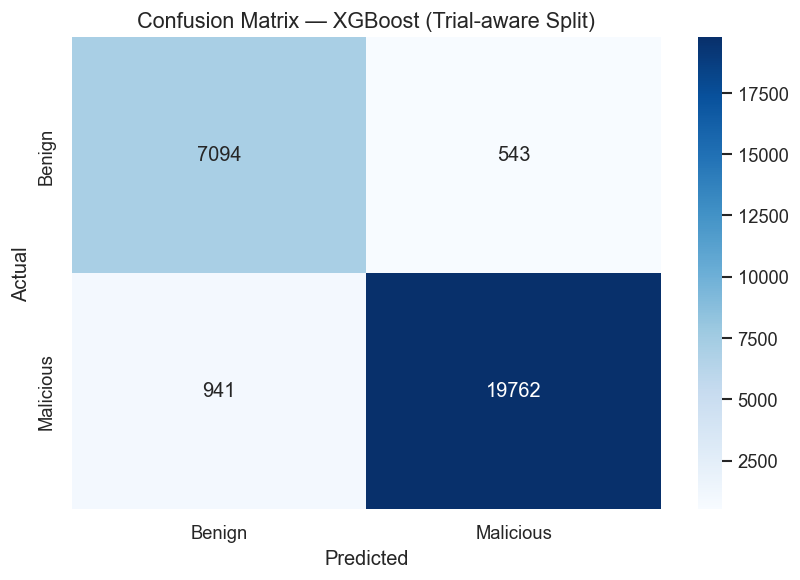

True Negatives  (Benign correctly detected)    : 7,094
False Positives (Benign flagged as ransomware) : 543
False Negatives (Ransomware missed)            : 941
True Positives  (Ransomware correctly detected): 19,762

False Positive Rate : 7.11%
False Negative Rate : 4.55%


In [10]:
## 6. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malicious"],
            yticklabels=["Benign", "Malicious"])
plt.title("Confusion Matrix — XGBoost (Trial-aware Split)", fontsize=13)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"True Negatives  (Benign correctly detected)    : {TN:,}")
print(f"False Positives (Benign flagged as ransomware) : {FP:,}")
print(f"False Negatives (Ransomware missed)            : {FN:,}")
print(f"True Positives  (Ransomware correctly detected): {TP:,}")
print(f"\nFalse Positive Rate : {FP/(FP+TN)*100:.2f}%")
print(f"False Negative Rate : {FN/(FN+TP)*100:.2f}%")

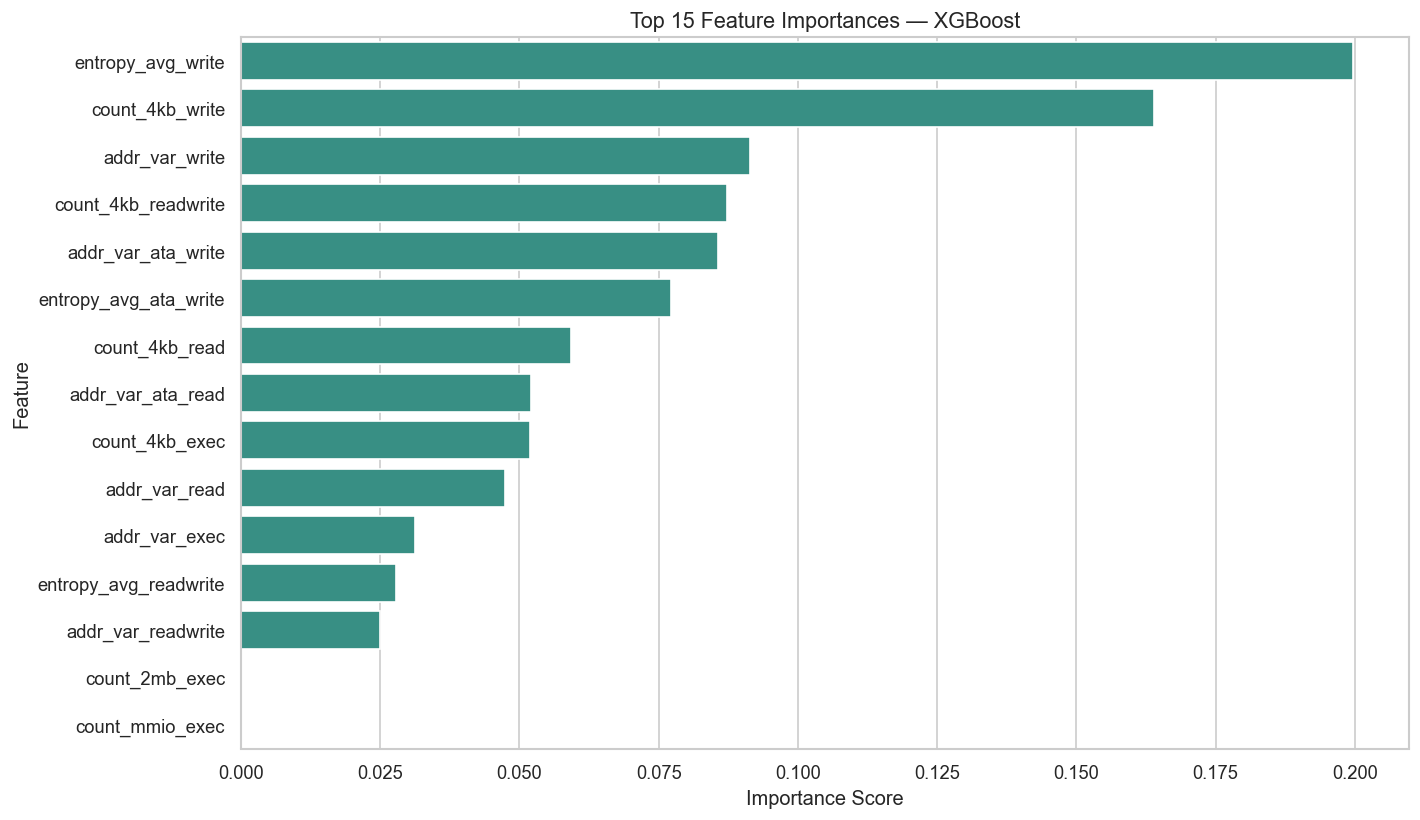

Top 10 most important features:
              Feature  Importance
    entropy_avg_write    0.199699
      count_4kb_write    0.163927
       addr_var_write    0.091416
  count_4kb_readwrite    0.087301
   addr_var_ata_write    0.085667
entropy_avg_ata_write    0.077204
       count_4kb_read    0.059331
    addr_var_ata_read    0.052081
       count_4kb_exec    0.051859
        addr_var_read    0.047358


In [11]:
## 7. Feature Importance

importance_df = pd.DataFrame({
    "Feature":    feat_cols,
    "Importance": xgb_final.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=importance_df.head(15), 
            x="Importance", y="Feature", color="#2A9D8F")
plt.title("Top 15 Feature Importances — XGBoost", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importance_df.head(10).to_string(index=False))

In [1]:
## 8. Final Results Summary

print("=" * 60)
print("  PHASE 4 — FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"""
BINARY CLASSIFICATION (malicious vs benign)
Cross-validation (trial-aware, 10-fold):

  Model           F1 Score   vs Paper
  Random Forest   0.9575     paper: 0.93 (memory only)
  XGBoost         0.9537     paper: n/a (not used)
  kNN             0.9285     paper: 0.92 (memory only)
  SVM             0.9183     paper: 0.88 (memory only)

Final Evaluation (trial-aware train/test split):
  Best Model      : XGBoost
  Accuracy        : 95%
  F1 (malicious)  : 0.96
  F1 (benign)     : 0.91
  False Positive  : 7.11% (benign flagged as ransomware)
  False Negative  : 4.55% (ransomware missed)

TOP 3 FEATURES:
  1. entropy_avg_write   — encryption signal
  2. count_4kb_write     — memory page access count
  3. addr_var_write      — scattered memory access

KEY IMPROVEMENTS OVER PAPER:
  + Trial-aware splitting — no data leakage
  + XGBoost added — not in original paper
  + 1970 trials vs paper's 1440 trials
  + All 4 splits used (original, extra, mix, variants)
  + 28 features vs paper's 18 features
""")

  PHASE 4 — FINAL RESULTS SUMMARY

BINARY CLASSIFICATION (malicious vs benign)
Cross-validation (trial-aware, 10-fold):

  Model           F1 Score   vs Paper
  Random Forest   0.9575     paper: 0.93 (memory only)
  XGBoost         0.9537     paper: n/a (not used)
  kNN             0.9285     paper: 0.92 (memory only)
  SVM             0.9183     paper: 0.88 (memory only)

Final Evaluation (trial-aware train/test split):
  Best Model      : XGBoost
  Accuracy        : 95%
  F1 (malicious)  : 0.96
  F1 (benign)     : 0.91
  False Positive  : 7.11% (benign flagged as ransomware)
  False Negative  : 4.55% (ransomware missed)

TOP 3 FEATURES:
  1. entropy_avg_write   — encryption signal
  2. count_4kb_write     — memory page access count
  3. addr_var_write      — scattered memory access

KEY IMPROVEMENTS OVER PAPER:
  + Trial-aware splitting — no data leakage
  + XGBoost added — not in original paper
  + 1970 trials vs paper's 1440 trials
  + All 4 splits used (original, extra, mix, varia

## Save Artifacts

In [13]:
import pickle, json, os

MODELS_DIR = r"C:\Users\Shiva\Downloads\RANSMAP_PROJECT\MODELS"
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Best model — XGBoost binary (your best performer)
with open(os.path.join(MODELS_DIR, 'model.pkl'), 'wb') as f:
    pickle.dump(xgb_final, f)
print(f"✅ model.pkl saved  (XGBoost binary, F1={f1_score(y_test, y_pred):.4f})")

# 2. Scaler — needed by app.py to scale inputs before predict
with open(os.path.join(MODELS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print("✅ scaler.pkl saved")

# 3. Feature column names — needed by app.py predictor page
with open(os.path.join(MODELS_DIR, 'feature_cols.pkl'), 'wb') as f:
    pickle.dump(feat_cols, f)
print(f"✅ feature_cols.pkl saved  ({len(feat_cols)} features)")

# 4. All trained models — for dashboard comparison
all_models = {
    'Random Forest': rf,
    'SVM':           svm,
    'kNN':           knn,
    'XGBoost':       xgb_final
}
with open(os.path.join(MODELS_DIR, 'all_models.pkl'), 'wb') as f:
    pickle.dump(all_models, f)
print("✅ all_models.pkl saved")

✅ model.pkl saved  (XGBoost binary, F1=0.9638)
✅ scaler.pkl saved
✅ feature_cols.pkl saved  (28 features)
✅ all_models.pkl saved


In [14]:
# Fit all models on full training data before saving
print("Fitting all models on training data...")

rf.fit(X_train, y_train)
print("RF fitted ✅")

svm.fit(X_scaled[train_idx], y_train)
print("SVM fitted ✅")

knn.fit(X_scaled[train_idx], y_train)
print("kNN fitted ✅")

# xgb_final already fitted ✅

# Now save all_models with properly fitted models
all_models = {
    'Random Forest': rf,
    'SVM':           svm,
    'kNN':           knn,
    'XGBoost':       xgb_final
}
with open(os.path.join(MODELS_DIR, 'all_models.pkl'), 'wb') as f:
    pickle.dump(all_models, f)
print("\n✅ all_models.pkl updated with fitted models!")

Fitting all models on training data...
RF fitted ✅
SVM fitted ✅
kNN fitted ✅

✅ all_models.pkl updated with fitted models!


## Conclusion

Phase 4 Model Building is complete.

**Validation strategy:**
- Trial-aware splitting using GroupShuffleSplit — prevents data leakage
- StratifiedGroupKFold 10-fold cross validation
- StandardScaler for SVM and kNN
- class_weight='balanced' and scale_pos_weight for class imbalance

**Binary Classification Results (malicious vs benign):**

| Model | F1 Score | Paper Equivalent |
|---|---|---|
| Random Forest | 0.9575 | 0.93 (memory only) |
| XGBoost | 0.9537 | not in paper |
| kNN | 0.9285 | 0.92 (memory only) |
| SVM | 0.9183 | 0.88 (memory only) |

**Best model — Random Forest:**
- Accuracy : 95%
- F1 (malicious) : 0.96
- F1 (benign) : 0.91
- False Positive Rate : 7.11%
- False Negative Rate : 4.55%

**Top feature — entropy_avg_write confirms the paper's core finding:**
Memory write entropy is the strongest signal for ransomware detection.

**Improvements over paper:**
- XGBoost added (new model not in paper)
- Trial-aware evaluation (no data leakage)
- 1970 trials vs paper's 1440
- 28 features vs paper's 18
- All 4 dataset splits used

**Next → Phase 5: Evaluation & Comparison**